In [1]:
!git clone https://github.com/MeowsQueen/Transformer-Based-Academic-Chatbot-with-Intent-Detection-and-RAG-lite-Response-Generation.git

Cloning into 'Transformer-Based-Academic-Chatbot-with-Intent-Detection-and-RAG-lite-Response-Generation'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 211 (delta 42), reused 18 (delta 18), pack-reused 150 (from 1)
Receiving objects: 100% (211/211), 614.99 KiB | 7.69 MiB/s, done.
Resolving deltas: 100% (95/95), done.


In [2]:
%cd /content/Transformer-Based-Academic-Chatbot-with-Intent-Detection-and-RAG-lite-Response-Generation

/content/Transformer-Based-Academic-Chatbot-with-Intent-Detection-and-RAG-lite-Response-Generation


In [3]:
!pip install -q pandas scikit-learn matplotlib joblib sentence-transformers streamlit torch transformers sentencepiece accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.4 MB/s eta 0:00:00


In [4]:
import sys
sys.path.append("/content/Transformer-Based-Academic-Chatbot-with-Intent-Detection-and-RAG-lite-Response-Generation")

In [5]:
import pandas as pd

train_df = pd.read_csv("data/processed/clinc_subset_train.csv")
val_df = pd.read_csv("data/processed/clinc_subset_val.csv")
test_df = pd.read_csv("data/processed/clinc_subset_test.csv")

print(train_df.head())
print(train_df["intent"].value_counts())

                                                text             intent
0                            what does tertiary mean      concept_query
1  can you hook me up with a meeting room on satu...  scheduling_action
2                    is it worth investing in target                oos
3       i want to know what the word discomfit means      concept_query
4  where can i find the cruise control on my kia ...                oos
intent
concept_query          100
scheduling_action      100
oos                    100
language_assistance    100
task_management        100
agent_identity         100
schedule_query         100
Name: count, dtype: int64


In [6]:
import pandas as pd

train_df = pd.read_csv("data/processed/clinc_subset_train.csv")
val_df = pd.read_csv("data/processed/clinc_subset_val.csv")
test_df = pd.read_csv("data/processed/clinc_subset_test.csv")

print(train_df.head())
print(train_df["intent"].value_counts())

                                                text             intent
0                            what does tertiary mean      concept_query
1  can you hook me up with a meeting room on satu...  scheduling_action
2                    is it worth investing in target                oos
3       i want to know what the word discomfit means      concept_query
4  where can i find the cruise control on my kia ...                oos
intent
concept_query          100
scheduling_action      100
oos                    100
language_assistance    100
task_management        100
agent_identity         100
schedule_query         100
Name: count, dtype: int64


In [7]:
!python src/train_intent_classifier.py

Validation Accuracy: 0.9357
Test Accuracy: 0.8857

Test Classification Report:

                     precision    recall  f1-score   support

     agent_identity     0.9310    0.9000    0.9153        30
      concept_query     0.9333    0.9333    0.9333        30
language_assistance     0.9286    0.8667    0.8966        30
                oos     0.7500    0.6000    0.6667        30
     schedule_query     0.8485    0.9333    0.8889        30
  scheduling_action     0.9091    1.0000    0.9524        30
    task_management     0.8788    0.9667    0.9206        30

           accuracy                         0.8857       210
          macro avg     0.8828    0.8857    0.8820       210
       weighted avg     0.8828    0.8857    0.8820       210


Saved model to: models/intent_classifier.pkl
Saved metrics to: results/metrics.txt
Saved confusion matrix to: results/confusion_matrix.png


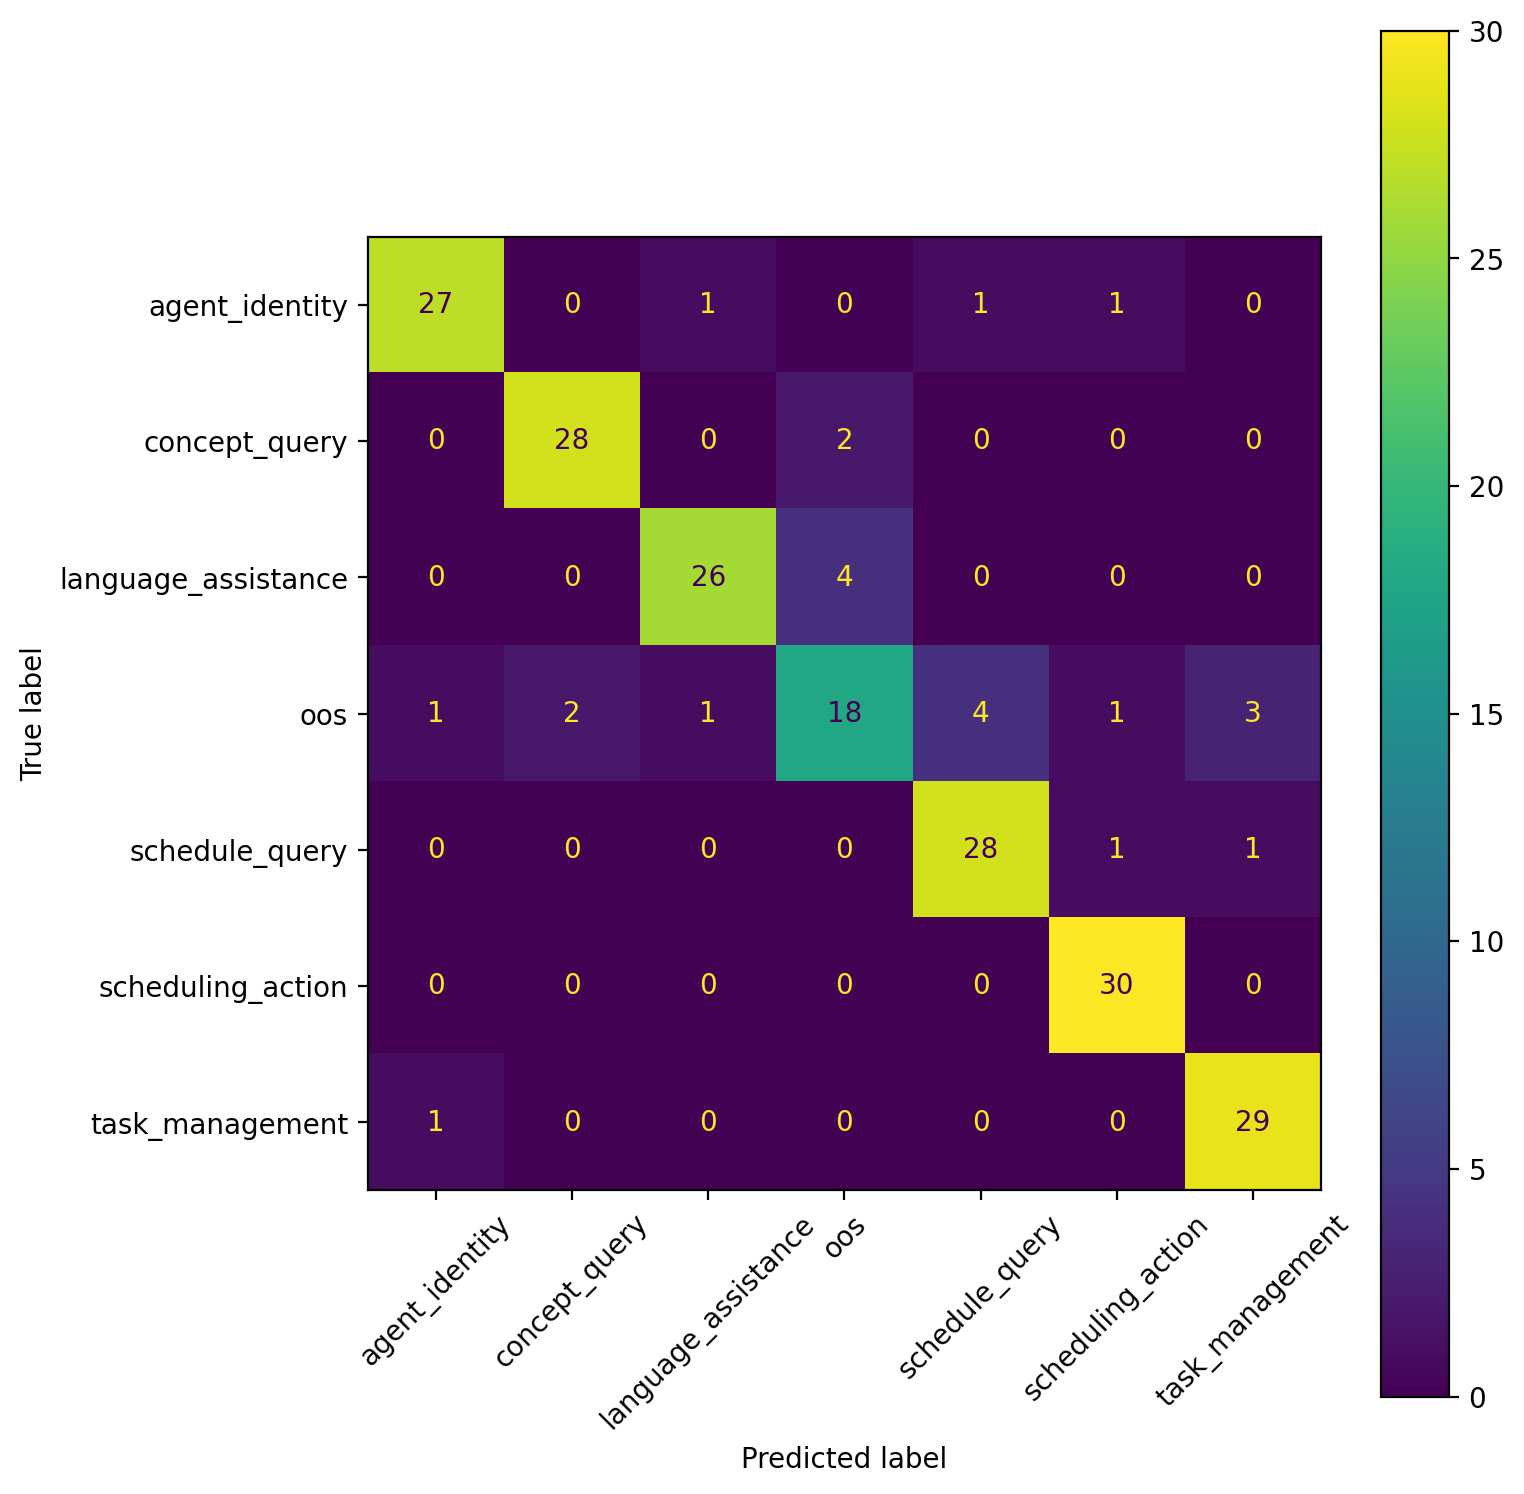

In [8]:
from PIL import Image
img = Image.open("results/confusion_matrix.png")
img

In [9]:
with open("results/metrics.txt", "r", encoding="utf-8") as f:
    print(f.read())

=== Validation Accuracy ===
0.9357

=== Test Accuracy ===
0.8857

=== Validation Classification Report ===
                     precision    recall  f1-score   support

     agent_identity     0.9091    1.0000    0.9524        20
      concept_query     0.9048    0.9500    0.9268        20
language_assistance     1.0000    1.0000    1.0000        20
                oos     0.9333    0.7000    0.8000        20
     schedule_query     0.9091    1.0000    0.9524        20
  scheduling_action     0.9524    1.0000    0.9756        20
    task_management     0.9474    0.9000    0.9231        20

           accuracy                         0.9357       140
          macro avg     0.9366    0.9357    0.9329       140
       weighted avg     0.9366    0.9357    0.9329       140


=== Test Classification Report ===
                     precision    recall  f1-score   support

     agent_identity     0.9310    0.9000    0.9153        30
      concept_query     0.9333    0.9333    0.9333        30

In [10]:
from src.retrieve import Retriever

retriever = Retriever()
results = retriever.retrieve("What is a transformer?", top_k=3, predicted_intent="concept_query")

for r in results:
    print("\n---")
    print("Score:", r["score"])
    print("Topic:", r["topic"])
    print("Answer hint:", r["answer_hint"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


---
Score: 0.672968864440918
Topic: transformers
Answer hint: A transformer is an attention-based sequence model widely used in modern NLP.

---
Score: 0.5092577934265137
Topic: transformers
Answer hint: Transformers are important because they enable strong contextual modeling and scalable training.

---
Score: 0.49217474460601807
Topic: course_content
Answer hint: Yes, transformers are a major part of the course.


In [11]:
from src.chatbot import Chatbot

bot = Chatbot()

queries = [
    "What is a transformer?",
    "Who is the instructor?",
    "How is the course graded?",
    "What topics are covered in the course?",
    "Is there a project in this course?",
    "What is the dropout rate of this course?",
    "Tell me a joke"
]

for q in queries:
    result = bot.respond(q)
    print("\n====================")
    print("Query:", q)
    print("Intent:", result["intent"])
    print("Response:", result["response"])

    if "retrieved_docs" in result:
        for doc in result["retrieved_docs"]:
            print(" -", doc["topic"], round(doc["score"], 4))

Loading intent classifier...
Loading retriever...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Query: What is a transformer?
Intent: concept_query
Response: A transformer is an attention-based sequence model widely used in modern NLP. (Based on course knowledge.)
 - transformers 0.673
 - transformers 0.5093
 - course_content 0.4922

Query: Who is the instructor?
Intent: agent_identity
Response: The course coordinator is Dr. Öğr. Üyesi Alper Öner. (Based on course knowledge.)
 - instructor 0.66
 - instructor 0.6247
 - instructor 0.5949

Query: How is the course graded?
Intent: schedule_query
Response: The course grade is based on assignment, project, and final exam, with the final exam carrying the highest weight. (Based on course knowledge.)
 - grading 0.7723
 - exam 0.62
 - grading 0.5885

Query: What topics are covered in the course?
Intent: schedule_query
Response: Yes, the course includes application-oriented topics and a practical project. (Based on course knowledge.)
 - course_content 0.7202
 - course_content 0.6484
 - course_content 0.613

Query: Is there a project in th

In [12]:
# Create sample_outputs.txt automatically
from src.chatbot import Chatbot

bot = Chatbot()

queries = [
    "What is a transformer?",
    "Who is the instructor?",
    "How is the course graded?",
    "What topics are covered in the course?",
    "Is there a project in this course?",
    "What is the dropout rate of this course?",
    "Tell me a joke"
]

lines = []

for q in queries:
    result = bot.respond(q)
    lines.append(f"Query: {q}")
    lines.append(f"Intent: {result['intent']}")
    lines.append(f"Response: {result['response']}")

    if "retrieved_docs" in result:
        topics = ", ".join([doc["topic"] for doc in result["retrieved_docs"]])
        lines.append(f"Retrieved Topics: {topics}")
    else:
        lines.append("Retrieved Topics: None")

    lines.append("")

with open("results/sample_outputs.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("Saved to results/sample_outputs.txt")

Loading intent classifier...
Loading retriever...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saved to results/sample_outputs.txt


In [13]:
!ls models
!ls results
!ls notebooks

intent_classifier.pkl  kb_embeddings.npy
confusion_matrix.png  metrics.txt  sample_outputs.txt
experiments.py	TEMP
